In [2]:
import cv2
import numpy as np
import PIL
import matplotlib.pyplot as plt

(900, 1200, 3)


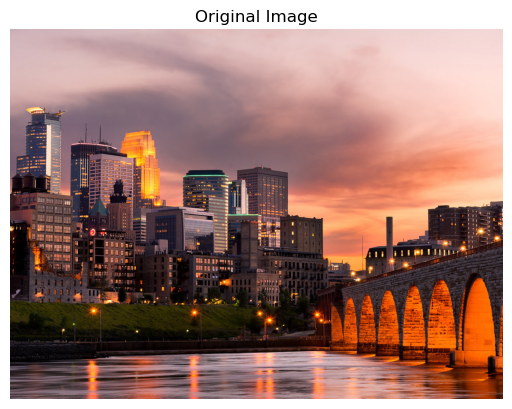

In [4]:
img = cv2.imread("cityscape.jpg")
#img = Image.open("modi-g-3.jpg")
image = np.array(img)
print(image.shape)
height, width, channels = image.shape

#Converting original image from BGR to RGB to make it matplotlib readable
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(1199.5), np.float64(899.5), np.float64(-0.5))

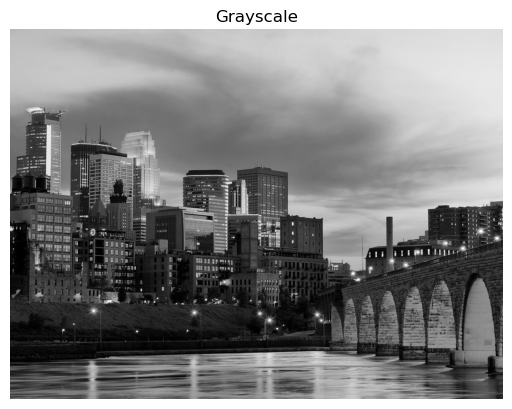

In [9]:
#converting the image to grayscale from RGB
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# image_o = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_gray, cmap = 'gray')
plt.title("Grayscale")
plt.axis('off')
#apply cmap for gray image

(np.float64(-0.5), np.float64(1199.5), np.float64(899.5), np.float64(-0.5))

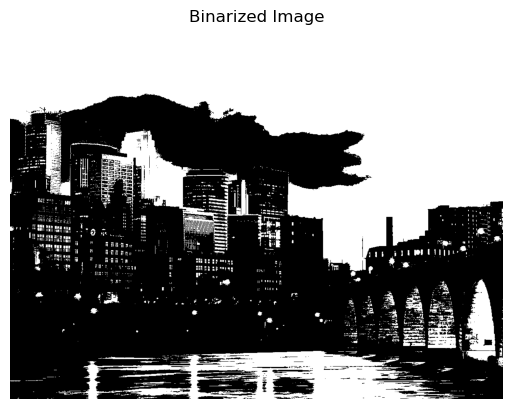

In [19]:
_, binary = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)
# binary_arr = np.array([binary])
# print(binary.shape)
plt.imshow(binary, cmap='gray')
plt.title("Binarized Image")
plt.axis('off')

In [31]:
#cv2.findContours(image, mode, method)
binary = cv2.bitwise_not(binary)

contours, hierarchy = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
output = binary.copy()
cv2.drawContours(binary, contours, -1, (0,255,0), 2)
print(len(contours))



196


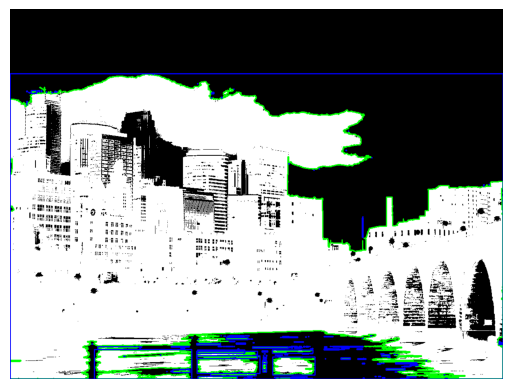

In [32]:
output = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, contours, -1, (0,255,0), 2)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output, (x,y), (x+w,y+h), (255,0,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()